# Customer Churn Prediction
## Preprocessing Technique 03 — Outlier Detection and Removal
**Member: Shakeer-IT25103397**

This notebook is adapted from the uploaded **Preprocessing + EDA Outliers** reference notebook and connected to the group churn-preprocessing pipeline.

### Input
`02_encoded_churn_data.csv`

### Main tasks
- Load and inspect the encoded churn dataset
- Select suitable numerical features for outlier analysis
- Detect outliers using the IQR method
- Visualize outliers using boxplots
- Visualize outlier counts
- Remove outlier rows
- Compare distributions before and after removal
- Check the churn distribution before and after removal
- Save the outlier-cleaned dataset for the next preprocessing notebook


In [1]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")


## 1. Load the Encoded Dataset

This notebook is the third stage of the preprocessing pipeline.

First run the encoding notebook and save its output as:

`02_encoded_churn_data.csv`


In [2]:
from google.colab import files

uploaded = files.upload()

Saving 02_encoded_churn_data.csv to 02_encoded_churn_data.csv


In [3]:
from pathlib import Path

possible_paths = [
    Path("/content/02_encoded_churn_data.csv"),
    Path("02_encoded_churn_data.csv")
]

file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        "02_encoded_churn_data.csv was not found. "
        "Run Notebook 02 - Encoding Categorical Variables first, "
        "or upload its output CSV to Colab."
    )

df = pd.read_csv(file_path)

print("Loaded file:", file_path)
print("Dataset shape:", df.shape)

df.head()


Loaded file: /content/02_encoded_churn_data.csv
Dataset shape: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


## 2. Initial Dataset Inspection


In [4]:
print("Dataset Information")
print("-" * 60)
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe().T)


Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB

Missing values:


,Missing Values
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0



Duplicate rows: 0

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Gender,10000.0,0.545700,0.497932,0.00,0.00,1.000,1.0000,1.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


## 3. Select Features for Outlier Detection

The IQR method should not be applied to binary indicator variables.

Therefore, the following continuous/count numerical features are checked:

- `CreditScore`
- `Age`
- `Tenure`
- `Balance`
- `NumOfProducts`
- `EstimatedSalary`

The following variables are **not** used for outlier removal:

- `Exited` — target variable
- `Gender` — binary encoded variable
- `HasCrCard` — binary variable
- `IsActiveMember` — binary variable
- `Geography_*` — one-hot encoded dummy variables


In [5]:
outlier_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

# Keep only columns that exist in the dataset
outlier_features = [
    col for col in outlier_features
    if col in df.columns
]

print("Features selected for outlier analysis:")
print(outlier_features)


Features selected for outlier analysis:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']


## 4. EDA Before Outlier Removal — Numerical Distributions

Histograms with KDE curves help us understand the shape, spread, and skewness of each numerical feature before outlier removal.


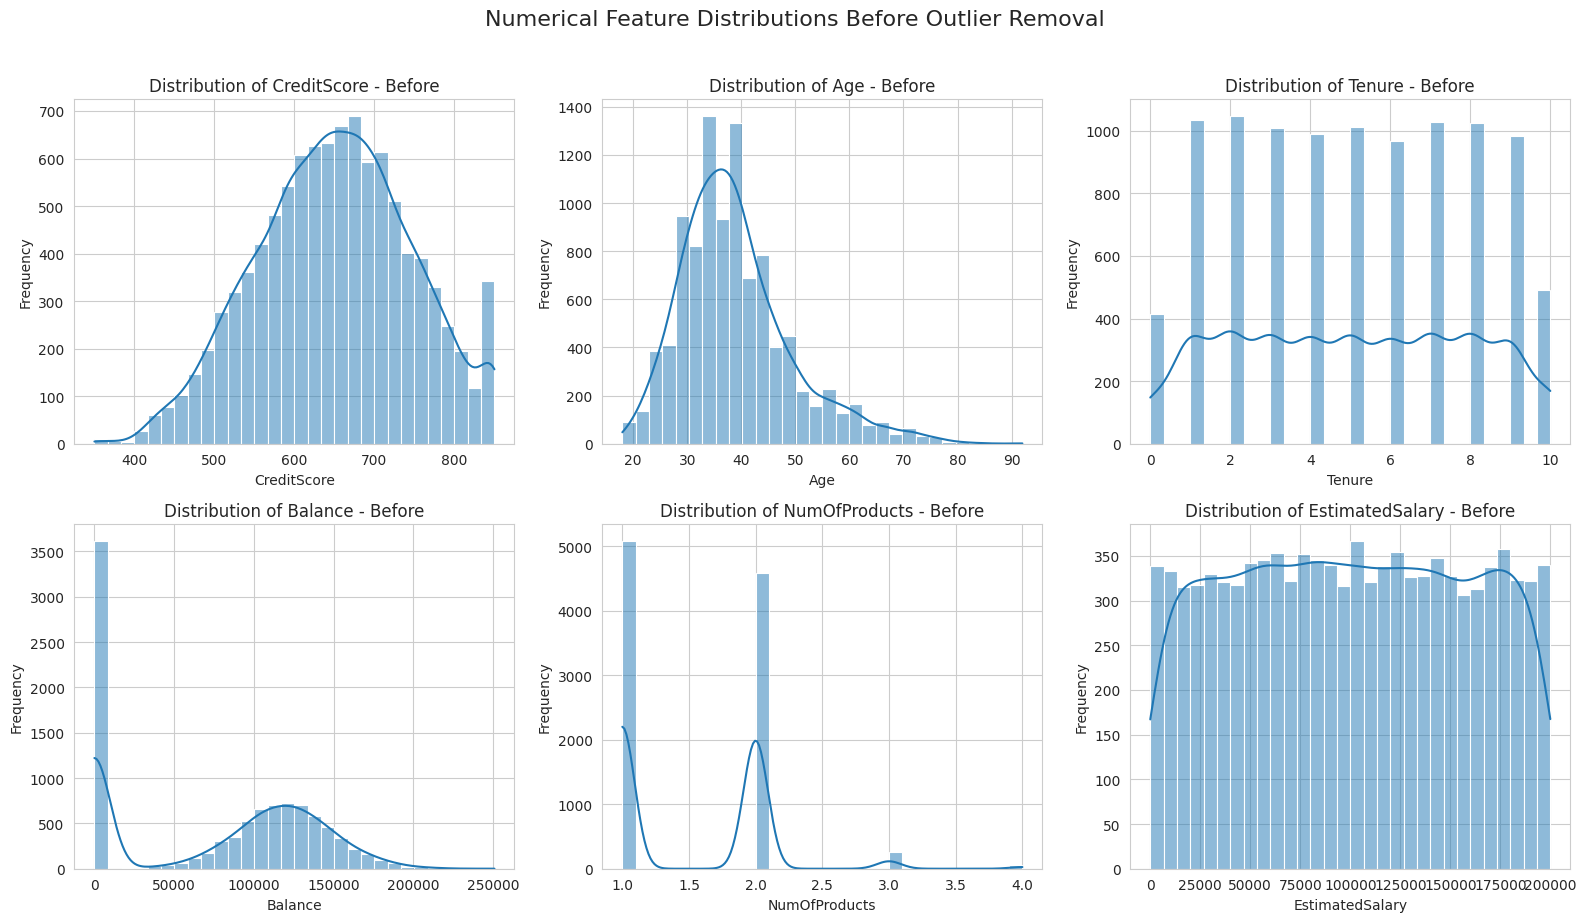

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col} - Before")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Numerical Feature Distributions Before Outlier Removal",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


## 5. EDA Before Outlier Removal — Boxplots

Boxplots are useful for visually identifying possible outliers.

Points outside the whiskers are potential outliers according to the boxplot/IQR rule.


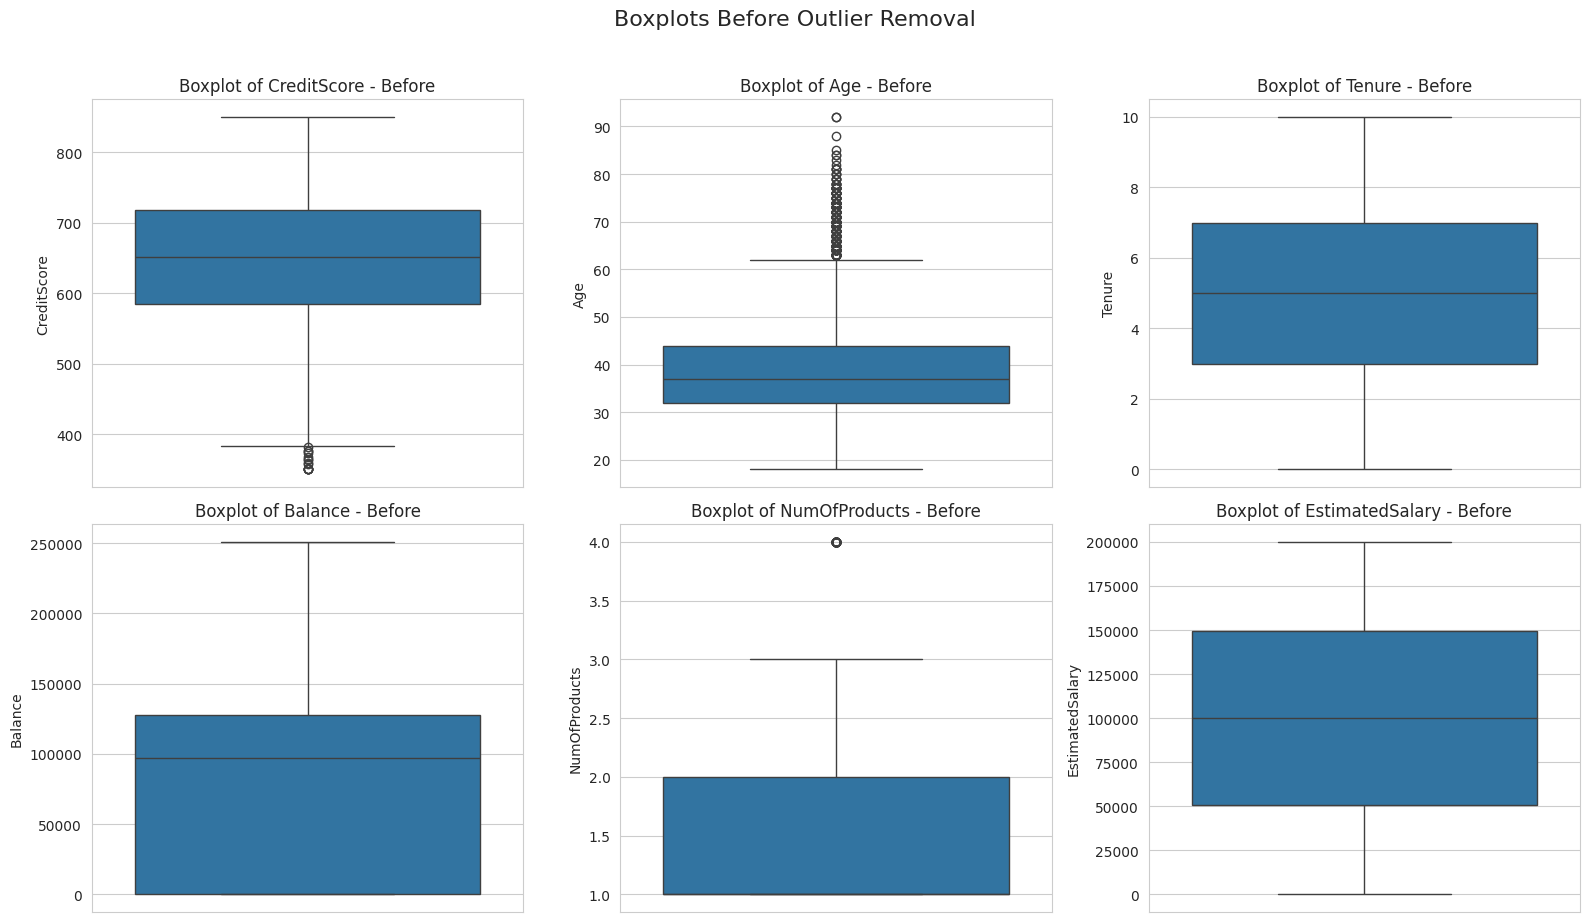

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col} - Before")

plt.suptitle(
    "Boxplots Before Outlier Removal",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


## 6. Detect Outliers Using the IQR Method

For each selected feature:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these limits are considered potential outliers.


In [8]:
outlier_summary = []

for col in outlier_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_count = outlier_mask.sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,CreditScore,584.00,718.0000,134.0000,383.00000,919.00000,15
1,Age,32.00,44.0000,12.0000,14.00000,62.00000,359
2,Tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0
3,Balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0
4,NumOfProducts,1.00,2.0000,1.0000,-0.50000,3.50000,60
5,EstimatedSalary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0


## 7. Visualize Number of Outliers by Feature


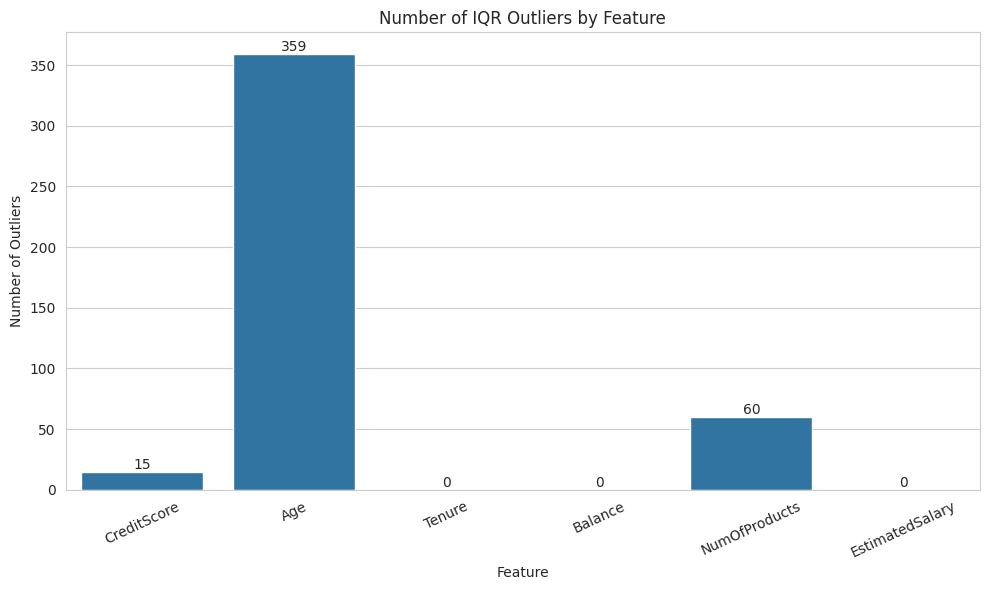

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=outlier_summary_df,
    x="Feature",
    y="Number of Outliers"
)

plt.title("Number of IQR Outliers by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=25)

for i, value in enumerate(outlier_summary_df["Number of Outliers"]):
    plt.text(
        i,
        value,
        str(int(value)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 8. Identify Rows Containing At Least One Outlier

A customer row is marked as an outlier row when at least one selected numerical feature falls outside its IQR limits.


In [10]:
combined_outlier_mask = pd.Series(
    False,
    index=df.index
)

outlier_bounds = {}

for col in outlier_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_bounds[col] = {
        "lower": lower_bound,
        "upper": upper_bound
    }

    combined_outlier_mask |= (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

total_outlier_rows = combined_outlier_mask.sum()

print("Total rows in dataset       :", len(df))
print("Rows containing outliers    :", total_outlier_rows)
print("Rows without detected outlier:", len(df) - total_outlier_rows)

print(
    "Percentage of rows flagged  : "
    f"{(total_outlier_rows / len(df)) * 100:.2f}%"
)


Total rows in dataset       : 10000
Rows containing outliers    : 432
Rows without detected outlier: 9568
Percentage of rows flagged  : 4.32%


In [11]:
# Display a sample of the detected outlier rows

outlier_rows = df.loc[
    combined_outlier_mask,
    outlier_features + ["Exited"]
]

print("Sample detected outlier rows:")
display(outlier_rows.head(20))


Sample detected outlier rows:


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited
7,376,29,4,115046.74,4,119346.88,1
58,511,66,4,0.00,1,1643.11,1
70,738,58,2,133745.44,4,28373.86,1
85,652,75,10,0.00,2,114675.75,0
104,670,65,1,0.00,1,177655.68,1
158,646,73,6,97259.25,1,104719.66,0
181,510,65,2,0.00,2,48071.61,0
230,673,72,1,0.00,2,111981.19,0
234,585,67,5,113978.97,2,93146.11,0
243,659,67,6,117411.60,1,45071.09,1


## 9. Target Distribution Before Outlier Removal

We inspect the churn target before removal so that we can later verify whether outlier removal changes the class distribution substantially.


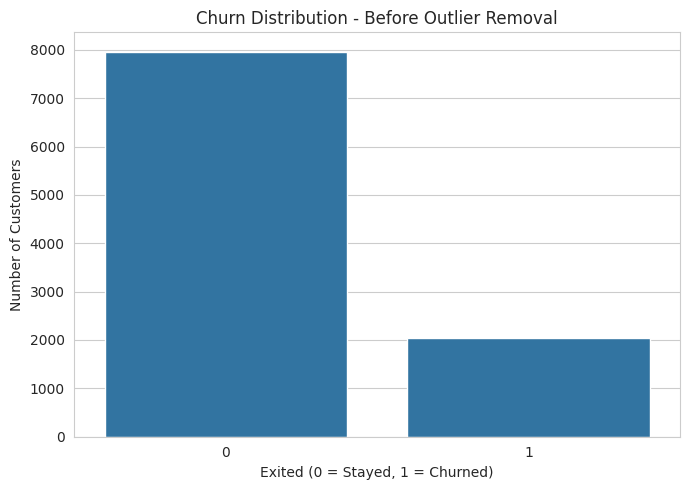

Exited
0    7963
1    2037
Name: count, dtype: int64

Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Exited"
)

plt.title("Churn Distribution - Before Outlier Removal")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print(df["Exited"].value_counts())
print("\nPercentage:")
print((df["Exited"].value_counts(normalize=True) * 100).round(2))


## 10. Remove Detected Outlier Rows

Rows containing at least one IQR outlier in the selected features are removed.

The original DataFrame is kept unchanged as `df`, while the cleaned dataset is stored in `df_no_outliers`.


In [13]:
rows_before = len(df)

df_no_outliers = (
    df.loc[~combined_outlier_mask]
      .copy()
      .reset_index(drop=True)
)

rows_after = len(df_no_outliers)

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal :", rows_after)
print("Rows removed               :", rows_before - rows_after)
print(
    "Percentage removed         : "
    f"{((rows_before - rows_after) / rows_before) * 100:.2f}%"
)


Rows before outlier removal: 10000
Rows after outlier removal : 9568
Rows removed               : 432
Percentage removed         : 4.32%


## 11. EDA After Outlier Removal — Boxplots

The boxplots are generated again to visually compare the numerical features after the detected outlier rows have been removed.


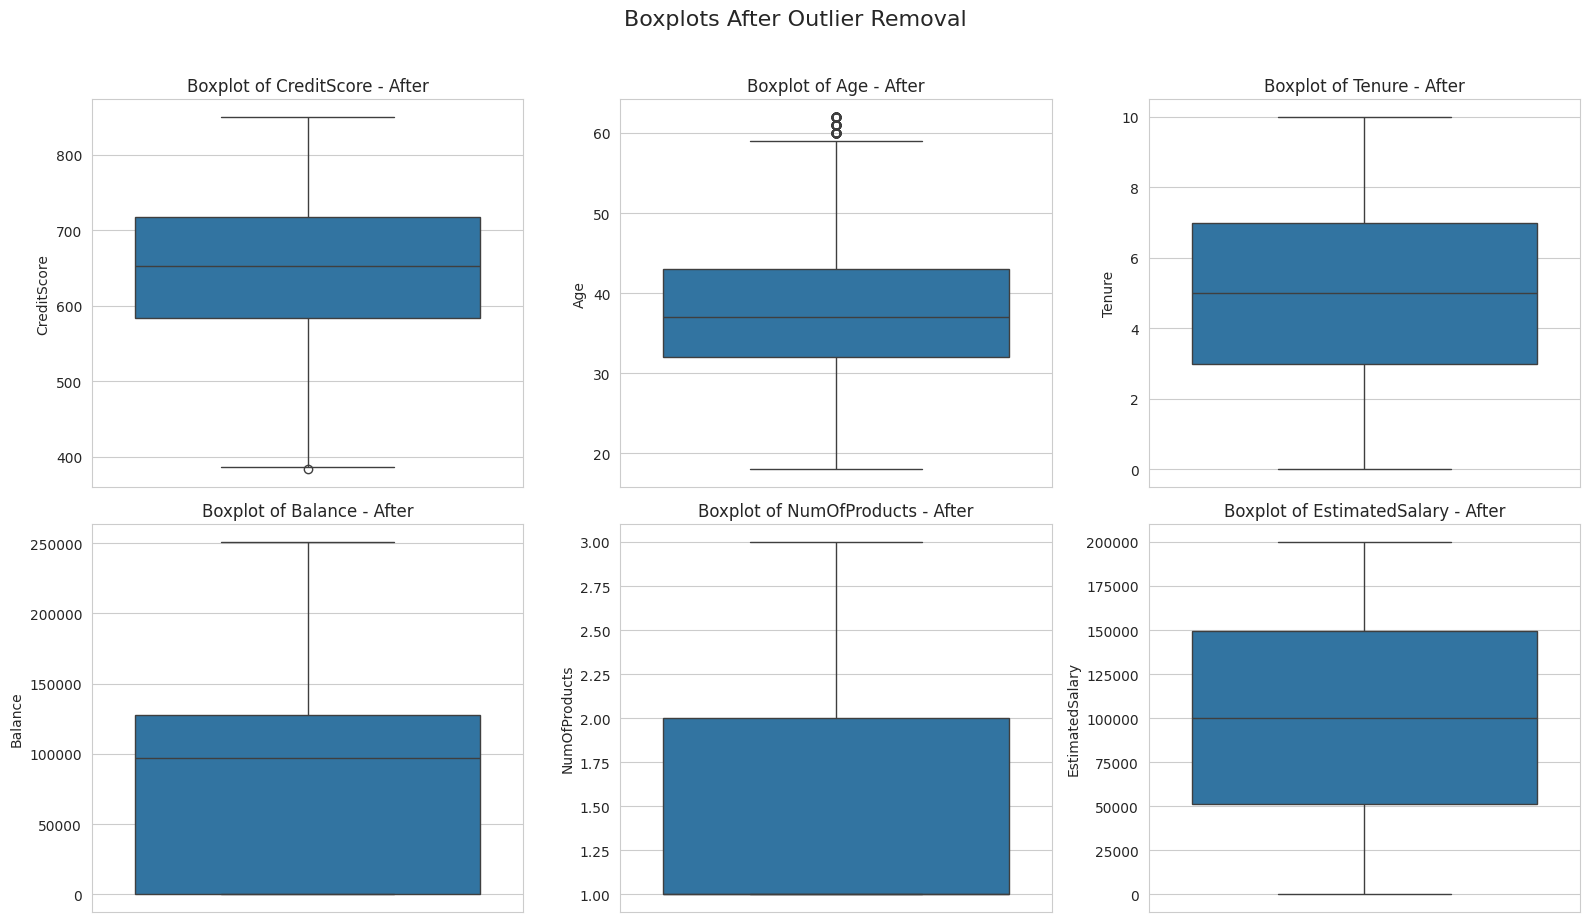

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.boxplot(
        data=df_no_outliers,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col} - After")

plt.suptitle(
    "Boxplots After Outlier Removal",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


## 12. EDA After Outlier Removal — Numerical Distributions


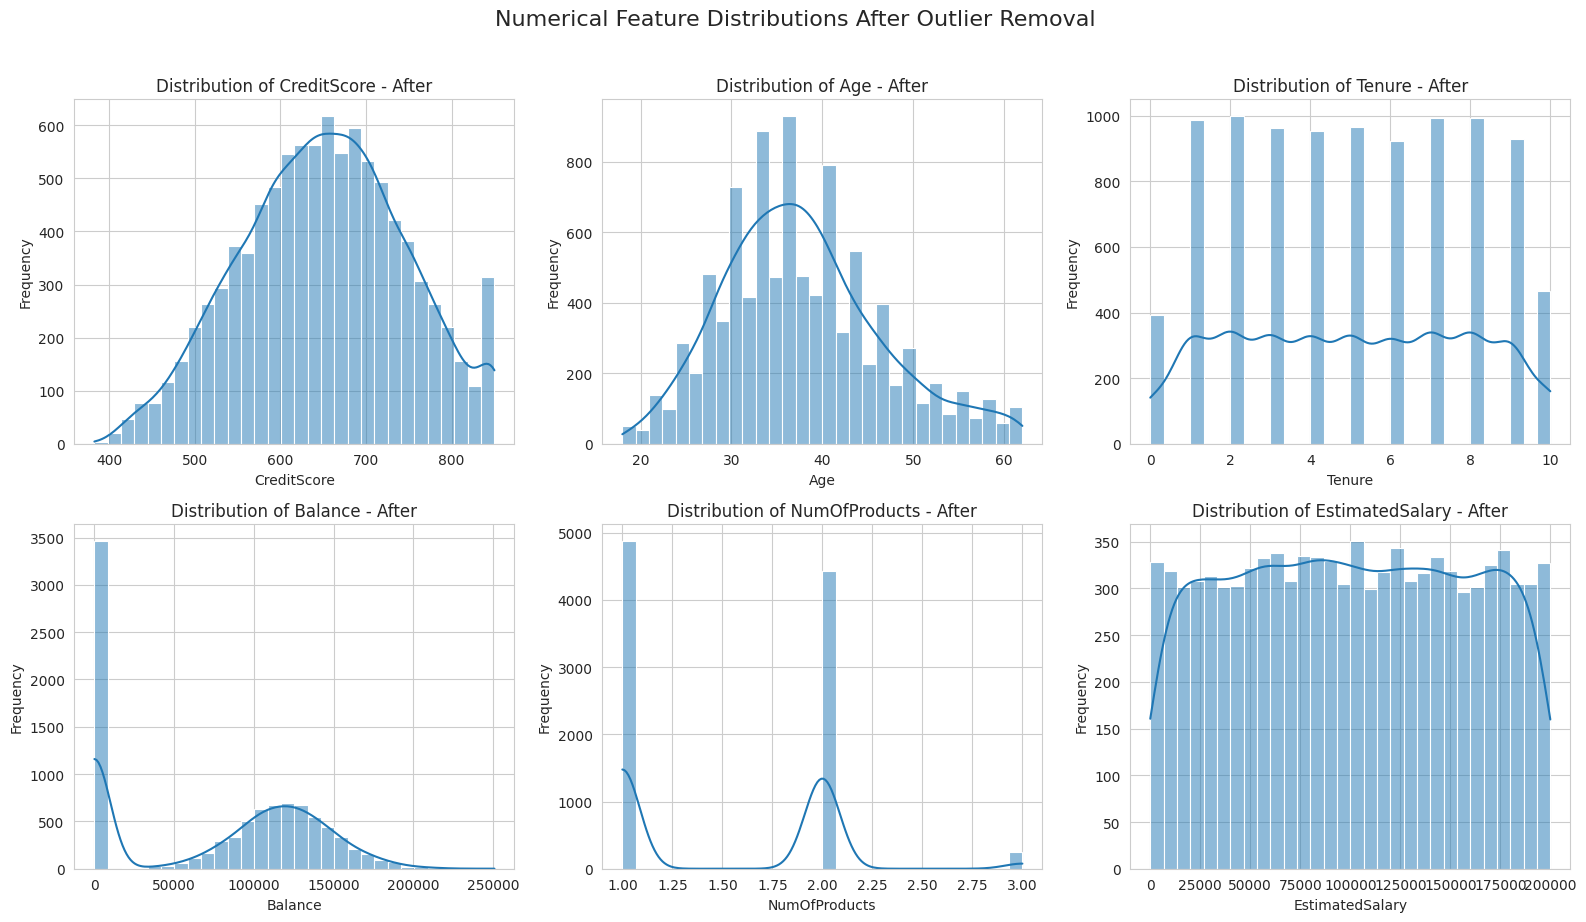

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    sns.histplot(
        data=df_no_outliers,
        x=col,
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col} - After")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Numerical Feature Distributions After Outlier Removal",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


## 13. Churn Distribution After Outlier Removal


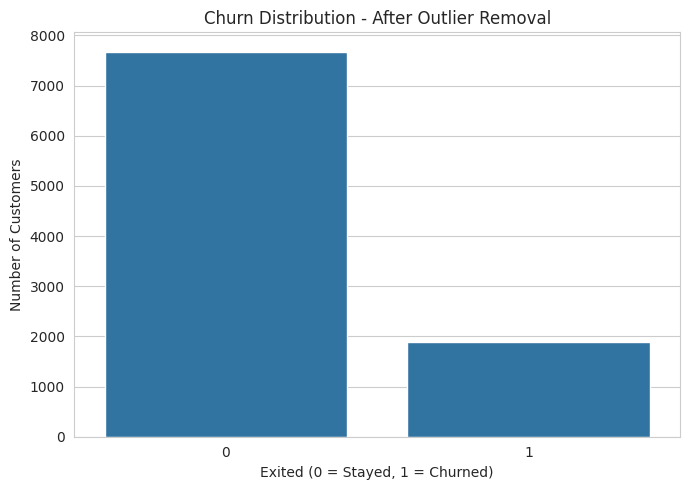

Exited
0    7677
1    1891
Name: count, dtype: int64

Percentage:
Exited
0    80.24
1    19.76
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_no_outliers,
    x="Exited"
)

plt.title("Churn Distribution - After Outlier Removal")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print(df_no_outliers["Exited"].value_counts())
print("\nPercentage:")
print(
    (
        df_no_outliers["Exited"]
        .value_counts(normalize=True) * 100
    ).round(2)
)


## 14. Before vs After Comparison


In [17]:
comparison = pd.DataFrame({
    "Measure": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Rows",
        "Class 0 Count",
        "Class 1 Count"
    ],

    "Before Outlier Removal": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Exited"] == 0).sum(),
        (df["Exited"] == 1).sum()
    ],

    "After Outlier Removal": [
        df_no_outliers.shape[0],
        df_no_outliers.shape[1],
        df_no_outliers.isnull().sum().sum(),
        df_no_outliers.duplicated().sum(),
        (df_no_outliers["Exited"] == 0).sum(),
        (df_no_outliers["Exited"] == 1).sum()
    ]
})

display(comparison)


,Measure,Before Outlier Removal,After Outlier Removal
0,Number of Rows,10000,9568
1,Number of Columns,12,12
2,Missing Values,0,0
3,Duplicate Rows,0,0
4,Class 0 Count,7963,7677
5,Class 1 Count,2037,1891


## 15. Compare Feature Statistics Before and After


In [18]:
before_stats = (
    df[outlier_features]
    .describe()
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
)

after_stats = (
    df_no_outliers[outlier_features]
    .describe()
    .T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
)

print("BEFORE OUTLIER REMOVAL")
display(before_stats)

print("\nAFTER OUTLIER REMOVAL")
display(after_stats)


BEFORE OUTLIER REMOVAL


,mean,std,min,25%,50%,75%,max
CreditScore,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48



AFTER OUTLIER REMOVAL


,mean,std,min,25%,50%,75%,max
CreditScore,650.690740,96.093507,383.00,584.0000,652.000,717.0000,850.00
Age,37.735786,8.782984,18.00,32.0000,37.000,43.0000,62.00
Tenure,5.015364,2.887869,0.00,3.0000,5.000,7.0000,10.00
Balance,76434.055500,62416.191144,0.00,0.0000,97089.635,127611.3325,250898.09
NumOfProducts,1.515991,0.549766,1.00,1.0000,1.000,2.0000,3.00
EstimatedSalary,100094.184752,57522.969343,11.58,51014.8375,100129.330,149461.8300,199992.48


## 16. Save the Outlier-Removed Dataset

This output becomes the input for the next preprocessing stage:

### Class Imbalance Handling — Sipna


In [19]:
output_file = "03_outlier_removed_churn_data.csv"

df_no_outliers.to_csv(
    output_file,
    index=False
)

print(f"Dataset saved as: {output_file}")
print("Final dataset shape:", df_no_outliers.shape)


Dataset saved as: 03_outlier_removed_churn_data.csv
Final dataset shape: (9568, 12)


In [20]:
from google.colab import files

files.download("03_outlier_removed_churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this preprocessing stage:

- Numerical features were analyzed using histograms and boxplots.
- Potential outliers were detected using the IQR method.
- Binary variables, dummy variables, and the target were excluded from IQR-based outlier detection.
- Rows containing detected outliers were removed.
- EDA visualizations were produced before and after outlier removal.
- The churn class distribution was checked before and after cleaning.
- The cleaned dataset was saved as `03_outlier_removed_churn_data.csv`.

The output is ready for the next preprocessing stage: **Class Imbalance Handling**.
